In [531]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


customers_df = pd.read_csv(r"C:\Users\shoha\Downloads\customers (1).csv")
items_df =  pd.read_csv(r"C:\Users\shoha\Downloads\items (1).csv")
orders_df =  pd.read_csv(r"C:\Users\shoha\Downloads\orders (1).csv")
order_item_df =  pd.read_csv(r"C:\Users\shoha\Downloads\order_item (1).csv")

customers_copy = customers_df.copy()
items_copy = items_df.copy()
orders_copy = orders_df.copy()
order_item_copy = order_item_df.copy()

# Data Preparation

In [532]:
##EX1.a.b.
dup_same_brand_name = items_copy[items_copy.duplicated(subset = ["item_name", "item_brand"], keep = False)]
dup_same_name_no_brand = items_copy[items_copy.duplicated(subset= "item_name", keep = False)].sort_values("item_name")

order_item_copy["item_id"] = order_item_copy["item_id"].replace(8,49)
items_copy = items_copy[items_copy["id"] != 8]



In [533]:
##EX2.a.b.
dup_same_email = customers_copy[customers_copy.duplicated(subset="email", keep=False)]
dup_same_email

,id,first_name,last_name,gender,age,nationallity,joining_date,phone_number,email


In [534]:
##EX3
missing_per_cus = customers_copy.isna().sum() * 100 / customers_copy.isna().count() 

customers_copy["gender"] = customers_copy["gender"].fillna("Unknown")
customers_copy["age"] = customers_copy["age"].fillna(round(customers_copy["age"].mean()))
customers_copy["joining_date"] = pd.to_datetime(customers_copy["joining_date"])
customers_copy["joining_date"] = customers_copy["joining_date"].fillna(customers_copy["joining_date"].mean())
customers_copy["joining_date"] = customers_copy["joining_date"].dt.date
missing_per_cus

missing_per_item = items_copy.isna().sum() * 100 / items_copy.isna().count() 

items_copy = items_copy.dropna(subset = "item_brand")
items_copy["item_category"] = items_copy["item_category"].fillna("Unknown")
items_copy["stock_quantity"] = items_copy["stock_quantity"].fillna(round(items_copy["stock_quantity"].mean()))
missing_per_item

missing_per_order = orders_copy.isna().sum() * 100 / orders_copy.isna().count()

orders_copy = orders_copy.dropna(subset="customer_id")
orders_copy["delivery_days"] = orders_copy["delivery_days"].fillna(round(orders_copy["delivery_days"].mean()))
missing_per_order

missing_per_order_item = order_item_copy.isna().sum() * 100 / order_item_copy.isna().count()
order_item_copy = order_item_copy.dropna(subset="item_id")
missing_per_order_item


Unnamed: 0    0.0
id            0.0
order_id      0.0
item_id       4.0
quantity      0.0
dtype: float64

# Data analysis

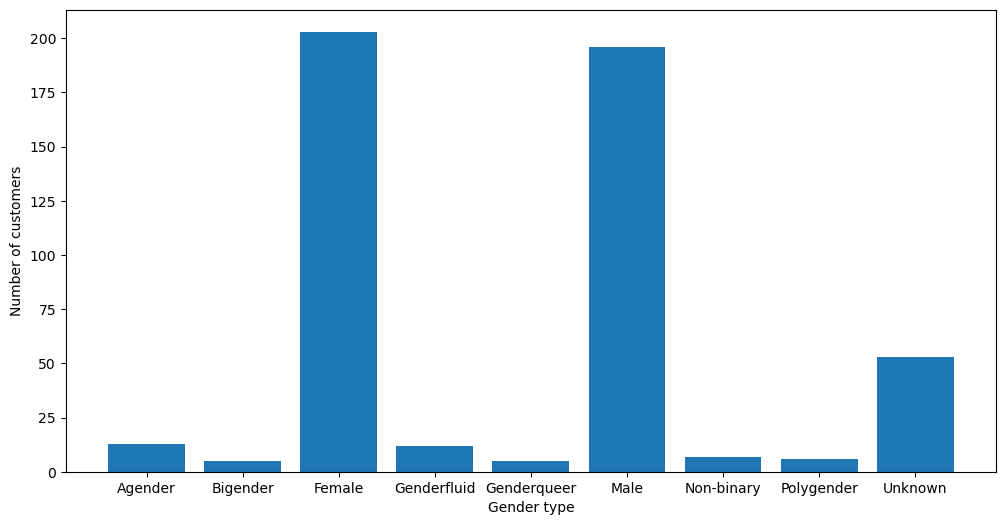

In [535]:
##EX1.a.
gender_count = customers_copy.groupby("gender").size().reset_index(name = "count")
plt.figure(figsize=(12,6))
plt.bar(gender_count["gender"], gender_count["count"])
plt.xlabel("Gender type")
plt.ylabel("Number of customers")
plt.show()

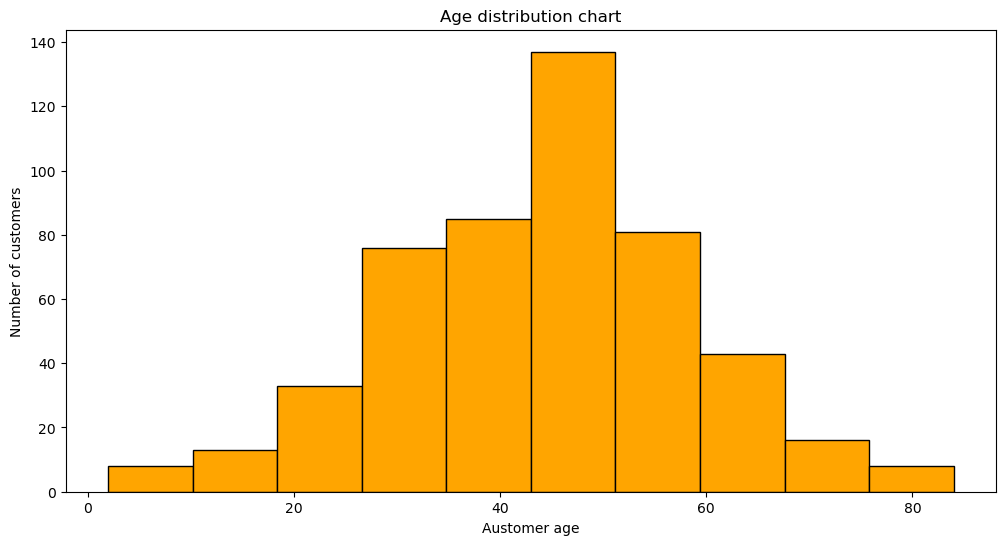

In [536]:
##EX1.b.
plt.figure(figsize=(12,6))
plt.hist(customers_copy["age"], bins=10, edgecolor = "black", color = "orange")
plt.title("Age distribution chart")
plt.xlabel("Austomer age")
plt.ylabel("Number of customers")
plt.show()

In [537]:
##EX1.c.
customers_copy["joining_date"] = pd.to_datetime(customers_copy["joining_date"])
customers_per_year = customers_copy.resample("YE", on="joining_date")["id"].count()
most_customers = customers_per_year.idxmax().year
most_customers

2021

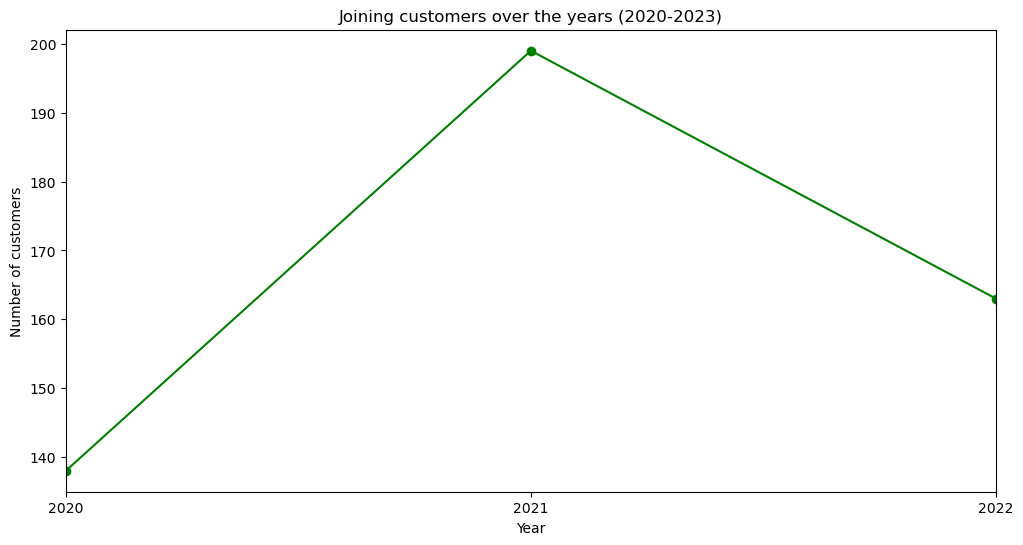

In [538]:
##EX1.d.
plt.figure(figsize=(12,6))
customers_per_year.plot(kind = "line", marker = "o", color = "green")
plt.title("Joining customers over the years (2020-2023)")
plt.xlabel("Year")
plt.ylabel("Number of customers")
plt.show()

##The graph does not show a consistent upwars of downward trend, there was a significant increase in 2021 and a decrease in 2022.

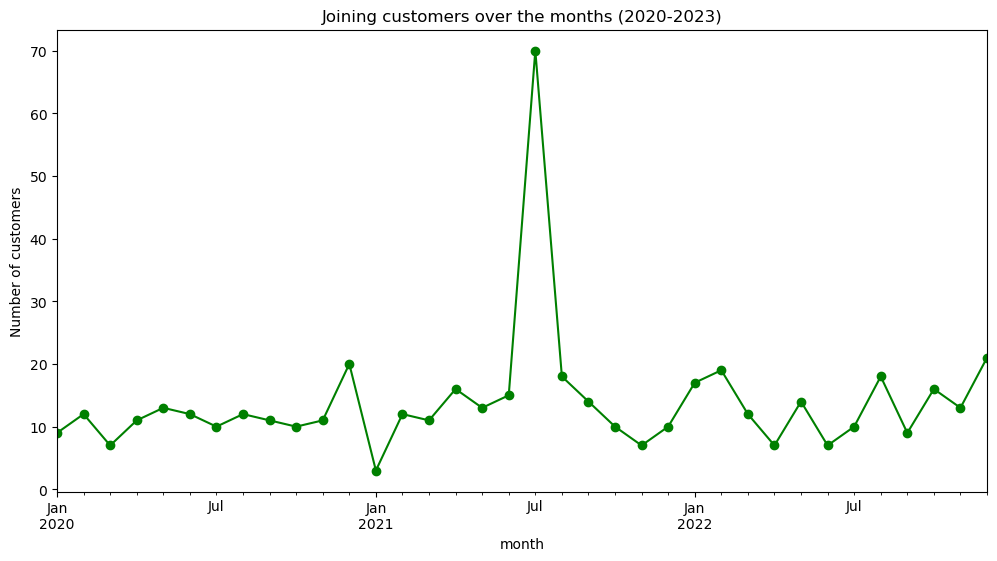

In [539]:
##EX1.e.
customers_per_month = customers_copy.resample("ME",on="joining_date")["id"].count() 
plt.figure(figsize=(12,6))
customers_per_month.plot(kind = "line", marker = "o", color = "green")
plt.title("Joining customers over the months (2020-2023)")
plt.xlabel("month")
plt.ylabel("Number of customers")
plt.show()

##The graph shows a significant increase in july 2021, other then that, there is no specific trend over the years.

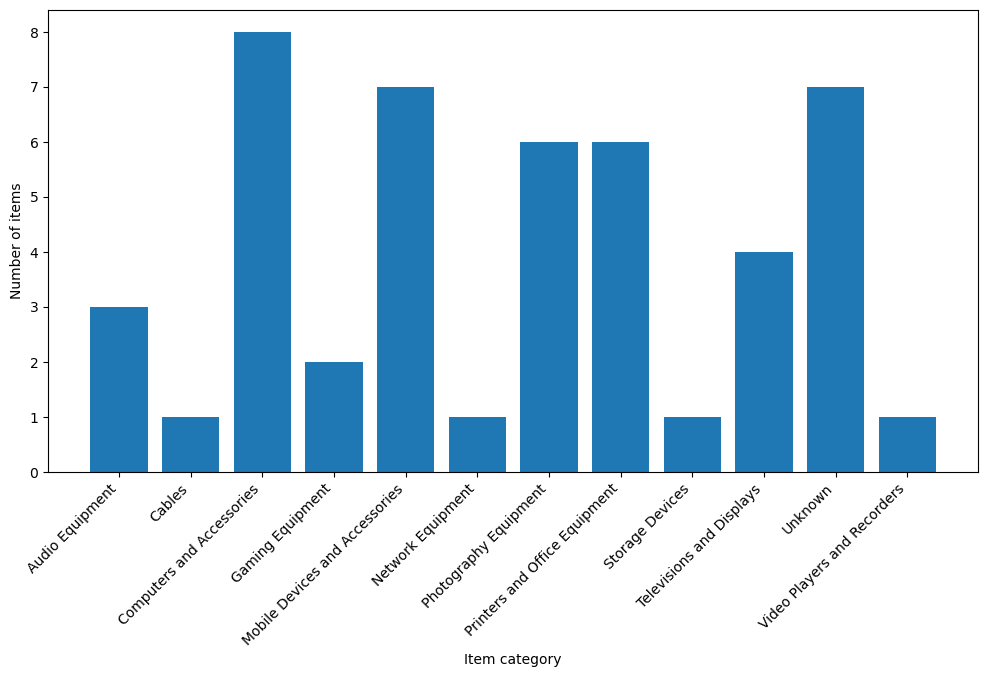

In [540]:
##EX2.a.
item_count = items_copy.groupby("item_category")["id"].count().reset_index(name = "count")
plt.figure(figsize=(12,6))
plt.xticks(rotation=45, ha="right")
plt.bar(item_count["item_category"], item_count["count"])
plt.xlabel("Item category")
plt.ylabel("Number of items")
plt.show()

In [541]:
##EX2.b.
valid_stock = items_copy[items_df["stock_quantity"].notna()]
largest_lowest_df = valid_stock.loc[[valid_stock["stock_quantity"].idxmax(),valid_stock["stock_quantity"].idxmin()]]

largest_lowest_df

C:\Users\shoha\AppData\Local\Temp\ipykernel_260\2587891391.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  valid_stock = items_copy[items_df["stock_quantity"].notna()]


,id,item_name,item_category,item_price,stock_quantity,item_brand,item_availability
40,41,VR Headset,Unknown,1905.01,1367.0,JBL,True
34,35,Wi-Fi Router,Network Equipment,3812.53,14.0,Microsoft,True


In [542]:
##EX2.c.
mean_stock = valid_stock["stock_quantity"].mean()
mean_stock

np.float64(749.7209302325581)

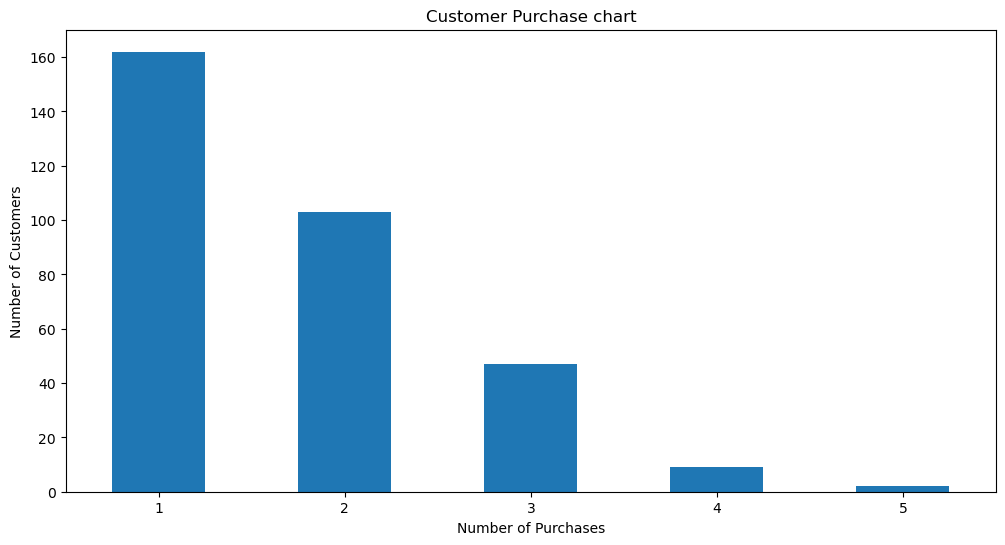

In [543]:
##EX3.a.
order_per_customer = orders_copy.groupby("customer_id")["order_id"].count()
purchase_numbers = order_per_customer.value_counts().sort_values(ascending=False)
plt.figure(figsize=(12,6))
purchase_numbers.plot(kind = "bar")
plt.title("Customer Purchase chart")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [544]:
##EX3.b.
top_customers = order_per_customer.reset_index(name = "order_count").sort_values("order_count", ascending=False).head(5)
top_customers.merge(customers_copy[["id","first_name","last_name"]], left_on="customer_id", right_on="id")


,customer_id,order_count,id,first_name,last_name
0,138.0,5,138,Ellary,Ledner
1,59.0,5,59,Merill,Lacroutz
2,151.0,4,151,Giorgio,Mence
3,204.0,4,204,Sharon,Wilby
4,63.0,4,63,Dorine,Cauldfield


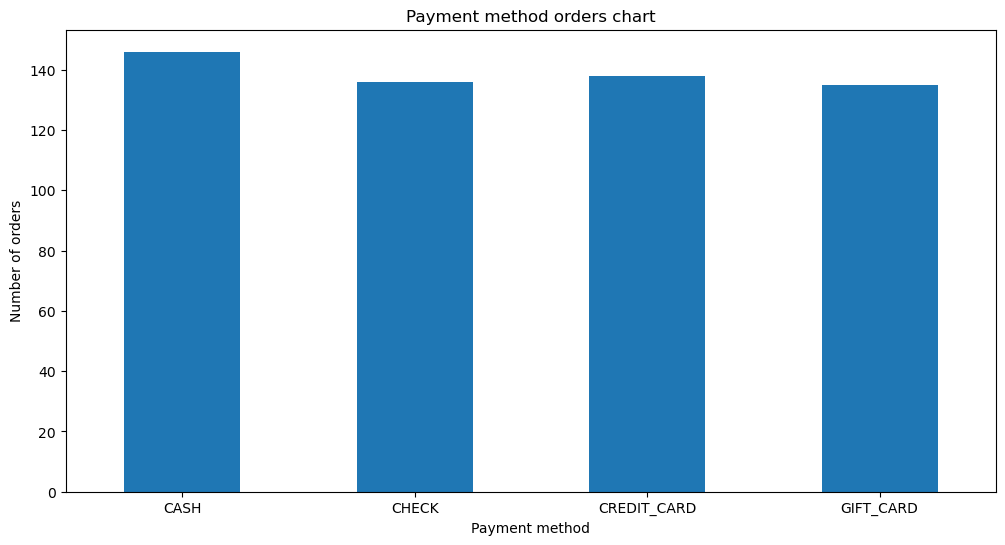

In [545]:
##EX3.c.
payment_orders = orders_copy.groupby("payment_method")["order_id"].count()
plt.figure(figsize=(12,6))
payment_orders.plot(kind = "bar")
plt.title("Payment method orders chart")
plt.xlabel("Payment method")
plt.ylabel("Number of orders")
plt.xticks(rotation=0)
plt.show()

In [546]:
##EX4.a.
order_total = order_item_copy.merge(items_copy[["id","item_price"]],left_on="item_id", right_on="id")
order_total["line_total"] = order_total["quantity"] * order_total["item_price"]

order_total_sum = order_total.groupby("order_id")["line_total"].sum().reset_index(name="total_price")

orders_copy = orders_copy.merge(order_total_sum, on="order_id", how="left")

orders_copy

,order_id,customer_id,delivery_address,delivery_days,order_date,payment_method,order_source,total_price
0,1,477.0,576 Cordelia Place,2.0,2023-12-05,GIFT_CARD,WEBSITE,8554.20
1,2,93.0,4664 6th Drive,4.0,2023-08-17,CASH,STORE,10148.58
2,3,474.0,8766 4th Point,4.0,2023-02-25,CHECK,STORE,6843.36
3,4,333.0,31 Bonner Way,3.0,2023-02-04,CASH,STORE,965.20
4,5,436.0,20352 Shelley Way,5.0,2023-06-01,CASH,STORE,63944.94
...,...,...,...,...,...,...,...,...
550,596,110.0,26 Hudson Lane,5.0,2023-10-30,CREDIT_CARD,WEBSITE,5270.24
551,597,209.0,37392 Sullivan Park,4.0,2023-08-23,CREDIT_CARD,WEBSITE,1710.84
552,598,480.0,1473 Ilene Drive,4.0,2023-09-11,CASH,STORE,NaN
553,599,72.0,2 Nancy Crossing,4.0,2023-02-09,CASH,STORE,29979.05


In [547]:
##EX4.b.
orders_copy["total_price"].agg(["max", "min","mean"]).reset_index()

,index,total_price
0,max,69581.820000
1,min,241.540000
2,mean,14088.706749


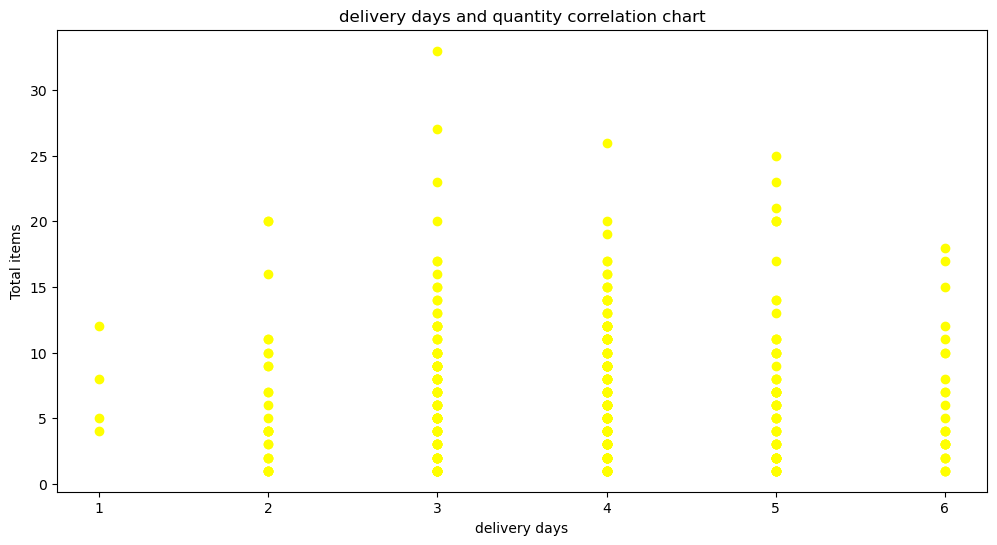

In [548]:
##EX4.c.
items_per_order = order_item_copy.groupby("order_id")["quantity"].sum().reset_index(name="total_items")
delivery_quantity_df  = orders_copy.merge(items_per_order, on="order_id")
delivery_quantity_df

plt.figure(figsize=(12,6))
plt.scatter(delivery_quantity_df["delivery_days"] ,delivery_quantity_df["total_items"], color = "yellow")
plt.title("delivery days and quantity correlation chart")
plt.xlabel("delivery days")
plt.ylabel("Total items")
plt.show()

##The graph shows no correlation between delivery days and quantity of items

In [549]:
##EX4.d.
customer_orders = customers_copy.merge(orders_copy["customer_id"],left_on="id",right_on="customer_id",how="left")
customers_without_orders = customer_orders[customer_orders["customer_id"].isna()]
len(customers_without_orders)

177

In [550]:
##EX4.e.
lowest_items = order_item_copy.groupby("item_id")["quantity"].sum().sort_values().head(5).reset_index()
lowest_items = lowest_items.merge(items_copy[["id","item_name"]], left_on="item_id", right_on="id")
lowest_items

,item_id,quantity,id,item_name
0,29.0,25,29,Webcam
1,33.0,27,33,Surge Protector
2,21.0,33,21,External Hard Drive
3,28.0,34,28,CCTV Camera
4,6.0,37,6,Printer


# Bonus → Decision making

In [560]:
##1
orders_copy
campaign_df = orders_copy.merge(customers_copy[["id","nationallity"]],left_on="customer_id", right_on="id")
campaign_df = campaign_df[(campaign_df["nationallity"] == "United States") & (campaign_df["order_source"] == "WEBSITE")]
campaign_df["order_date"] = pd.to_datetime(campaign_df["order_date"])

before_campaign = campaign_df[(campaign_df["order_date"] >= "2023-01-01") & (campaign_df["order_date"] < "2023-08-01")]
after_campaign = campaign_df[campaign_df["order_date"] >= "2023-08-01"]



In [561]:
##len(before_campaign)
39
len(after_campaign)
##17

17

In [563]:
before_campaign["total_price"].sum()
##296652.64
after_campaign["total_price"].sum()
##248076.66

np.float64(296652.64999999997)

#### The campaign does not apper useful, based on total customers before and after and based on total revenue

In [565]:
##2
gift_card_use = campaign_df[(campaign_df["payment_method"] == "GIFT_CARD")]
before = gift_card_use[(gift_card_use["order_date"] >= "2023-01-01") & (gift_card_use["order_date"] < "2023-08-01")]
after = gift_card_use[gift_card_use["order_date"] >= "2023-08-01"]


In [567]:
len(before)
##12
len(after)
##6

6

In [556]:
before["total_price"].sum()
##142258.02
after["total_price"].sum()
##87387.13

np.float64(87387.13999999998)

#### THE discount prices also does not apper useful, did not increase sales or the use of gift cards, based on revenue and total customers before and after the campaign